### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
ALGOS = ['mcsplit', 'rl', 'll', 'dal', 'dsb', 'rrsplit', 'symsplit']
DATA_DIR = Path('../../hpc/cross-dataset-evaluation/results')

COLS = [
    'instance_a', 'instance_b', 'algo',
    'unified_size', 'unified_edges', 'unified_nodes', 'unified_time',
    'unified_aborted', 'unified_nodes_to_best',
    'unified_time_to_best', 'unified_cut_branches', 'unified_bound_pruned',
    'unified_sym_pruned'
]

In [3]:
dfs = []
for algo in ALGOS:
    path = DATA_DIR / f'{algo}_bi_all.csv'
    if not path.exists():
        print(f'WARNING: {path} not found, skipping {algo}')
        continue
    df = pd.read_csv(path, header=None, names=COLS)
    dfs.append(df)
    print(f'Loaded {algo}: {len(df)} rows')

all_data = pd.concat(dfs, ignore_index=True)

# Type coercions
for col in ['unified_size', 'unified_aborted', 'unified_time']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

print(f'\nTotal rows loaded: {len(all_data)}')

Loaded mcsplit: 9180 rows
Loaded rl: 9180 rows
Loaded ll: 9180 rows

Total rows loaded: 27540


### 3. Per-Algorithm Completion Summary

In [4]:
summary_rows = []
for algo in ALGOS:
    sub = all_data[all_data['algo'] == algo]
    if sub.empty:
        continue
    total = len(sub)
    row = {
        'algo': algo,
        'total': total,
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('algo')

In [5]:
print(summary_df.round(3))

         total
algo          
mcsplit   9180
rl        9180
ll        9180


### 4. Cross-Algorithm Correctness Check

In [6]:
completed = all_data[
    (all_data['unified_aborted'] == 0) &
    (all_data['unified_size'].notna())
][['instance_a', 'instance_b', 'algo', 'unified_size']]

pivot = completed.pivot_table(
    index=['instance_a', 'instance_b'],
    columns='algo',
    values='unified_size',
    aggfunc='first'
)

def classify(row):
    vals = row.dropna()
    if len(vals) < 2:
        return 'INSUFFICIENT_DATA'
    if vals.nunique() > 1:
        return 'REAL_MISMATCH'
    return 'OK'

pivot['status'] = pivot.apply(classify, axis=1)
status_counts = pivot['status'].value_counts()

In [7]:
pivot

algo                      ll  mcsplit     rl status
instance_a instance_b                              
001.txt    002.txt    46.000   46.000 46.000     OK
           003.txt    10.000   10.000 10.000     OK
           004.txt    12.000   12.000 12.000     OK
           008.txt    17.000   17.000 17.000     OK
           010.txt    16.000   16.000 16.000     OK
...                      ...      ...    ...    ...
176.txt    192.txt    27.000   27.000 27.000     OK
           196.txt    23.000   23.000 23.000     OK
177.txt    192.txt    28.000   28.000 28.000     OK
           196.txt    23.000   23.000 23.000     OK
192.txt    196.txt    21.000   21.000 21.000     OK

[7282 rows x 4 columns]

In [8]:
print(len(pivot[pivot['status'] == "OK"]))

7152


In [9]:
print(len(pivot[pivot['status'] == "INSUFFICIENT_DATA"]))

130


In [10]:
print(len(pivot[pivot['status'] == "REAL_MISMATCH"]))

0


In [11]:
mismatches = pivot[pivot['status'] == 'REAL_MISMATCH']
if mismatches.empty:
    print('\nZero real mismatches - all completed algorithms agree on every instance.')
else:
    print(f'\nREAL MISMATCHES ({len(mismatches)}):')
    display(mismatches.drop(columns='status'))


Zero real mismatches - all completed algorithms agree on every instance.


### 5. Grouping Instances by Difficulty

In [12]:
ALGO_ORDER = ['mcsplit', 'rl', 'll']

In [13]:
num_cols = ['unified_size', 'unified_nodes', 'unified_time', 'unified_aborted']
for col in num_cols:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_data = all_data[all_data['algo'].isin(ALGO_ORDER)].copy()

In [34]:
TIMEOUT = 1000.0
EASY_THRESHOLD = 10

inst_key = ['instance_a', 'instance_b']

solved = all_data.copy()

# Unified solve time (NaN if aborted)
solved['solve_time'] = solved.apply(
    lambda r: r['unified_time'] if r['unified_aborted'] == 0 else np.nan, axis=1
)

time_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='solve_time', aggfunc='first'
)
abort_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='unified_aborted', aggfunc='first'
)

# Combined abort: 1 if EITHER unified OR reference timed out, NaN treated as aborted
abort_pivot_any = (
    (abort_pivot.fillna(1).astype(int) == 1)
).astype(int)

# All unique instance pairs in the dataset
all_instances = all_data[inst_key].drop_duplicates().set_index(inst_key).index

def classify_instance(idx):
    # Check if instance exists in pivot (has at least some non-missing data)
    if idx not in abort_pivot_any.index:
        return 'hard'   # no data at all — all algos timed out, no ref data either

    row_abort = abort_pivot_any.loc[idx]
    row_time  = time_pivot.loc[idx] if idx in time_pivot.index else pd.Series(dtype=float)

    n_solved    = (row_abort == 0).sum()
    n_with_data = row_abort.notna().sum()
    n_fast      = (row_time <= EASY_THRESHOLD).sum()

    if n_solved == 0:
        return 'hard'
    if n_fast == n_with_data:
        return 'easy'
    return 'medium'

difficulty = pd.Series(
    [classify_instance(idx) for idx in all_instances],
    index=all_instances,
    name='difficulty'
)

In [35]:
print("Instance difficulty distribution (unified + reference, cross-algorithm):")
print(difficulty.value_counts())

Instance difficulty distribution (unified + reference, cross-algorithm):
difficulty
easy      6322
hard      1898
medium     960
Name: count, dtype: int64


#### Unified

In [36]:
medium_instances = set(difficulty[difficulty == 'medium'].index)

# Filter all_data to just medium instances
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

medium_summary = medium_data.groupby('algo').apply(
    lambda x: pd.Series({
        'medium_total': len(x),
        'solved': (x['unified_aborted'] == 0).sum(),
        'solved_pct': 100 * (x['unified_aborted'] == 0).mean(),
        # 'mean_time': x.loc[x['unified_aborted'] == 0, 'unified_time'].mean(),
        # 'mean_nodes': x.loc[x['unified_aborted'] == 0, 'unified_nodes'].mean(),
    }),
    include_groups=False
).reindex(ALGO_ORDER)

In [37]:
medium_summary

,medium_total,solved,solved_pct
algo,,,
mcsplit,960.000,723.000,75.312
rl,960.000,840.000,87.500
ll,960.000,894.000,93.125


In [38]:
# Combine unified and reference medium-instance results with ranks
comparison = pd.DataFrame({
    ('Unified', 'solved'):     medium_summary['solved'],
    # ('Unified', 'solved_%'):   medium_summary['solved_pct'],
    ('Unified', 'rank'):       medium_summary['solved'].rank(ascending=False, method='min').astype(int)
}).reindex(ALGO_ORDER)

comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)

In [39]:
print(f"Shared medium instance set: {int(medium_summary['medium_total'].iloc[0])} instances\n")
print(comparison)

Shared medium instance set: 960 instances

        Unified     
         solved rank
algo                
mcsplit 723.000    3
rl      840.000    2
ll      894.000    1


### 6. Overhead Analysis

In [40]:
# Time per node (microseconds) — proxy for per-node overhead
medium_data['time_per_node_us'] = (
    medium_data['unified_time'] / medium_data['unified_nodes'] * 1e6
)

# Only on completed instances (aborted ones have truncated node counts)
completed = medium_data[medium_data['unified_aborted'] == 0]

time_per_node = completed.groupby('algo')['time_per_node_us'].agg(['mean', 'median'])

In [41]:
print("Unified time per node (microseconds):")
print(time_per_node.reindex(ALGO_ORDER).round(4))

Unified time per node (microseconds):
         mean  median
algo                 
mcsplit 0.086   0.076
rl      0.131   0.117
ll      0.134   0.122


### 8. Runtime Analysis

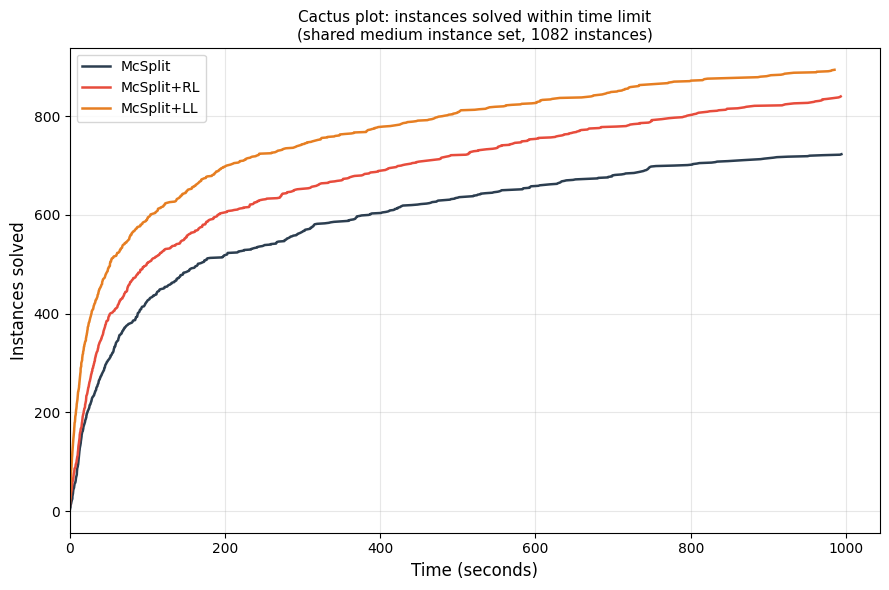

In [42]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {
    'mcsplit': '#2c3e50',
    'rl':      '#e74c3c',
    'll':      '#e67e22',
    'dal':     '#f1c40f',
    'dsb':     '#2ecc71',
    'rrsplit': '#3498db',
    'symsplit':'#9b59b6'
}
LABELS = {
    'mcsplit': 'McSplit',
    'rl':      'McSplit+RL',
    'll':      'McSplit+LL',
    'dal':     'McSplit+DAL',
    'dsb':     'McSplit+DSB',
    'rrsplit': 'RRSplit',
    'symsplit':'SymSplit'
}

# Use medium instances only for the fair comparison
medium_instances = set(difficulty[difficulty == 'medium'].index)
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

fig, ax = plt.subplots(figsize=(9, 6))

for algo in ALGOS:
    sub = medium_data[
        (medium_data['algo'] == algo) &
        (medium_data['unified_aborted'] == 0)
    ]['unified_time'].sort_values().values

    if len(sub) == 0:
        continue

    # x = cumulative instance count, y = time to solve that many
    x = np.arange(1, len(sub) + 1)
    ax.plot(sub, x, label=LABELS[algo], color=COLORS[algo], linewidth=1.8)

ax.set_ylabel('Instances solved', fontsize=12)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Cactus plot: instances solved within time limit\n(shared medium instance set, 1082 instances)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(left=0)
# ax.set_ylim(bottom=0, top=TIMEOUT)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cactus_time.png', dpi=150)
plt.show()
# print("Saved: cactus_time.png")

### 9. Node Analysis

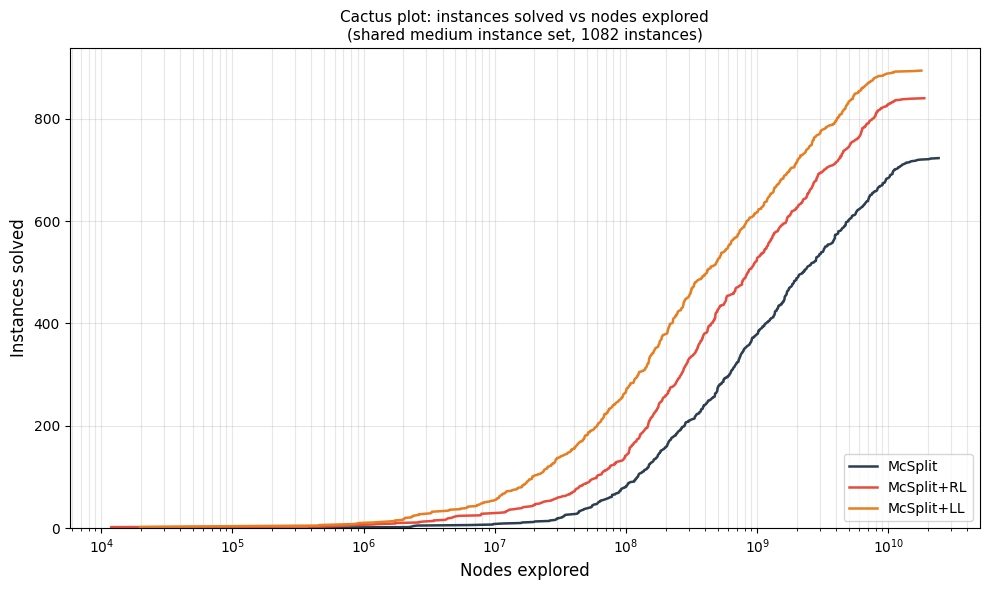

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))

for algo in ALGOS:
    sub = medium_data[
        (medium_data['algo'] == algo) &
        (medium_data['unified_aborted'] == 0)
    ]['unified_nodes'].sort_values().values

    if len(sub) == 0:
        continue

    y = np.arange(1, len(sub) + 1)
    ax.plot(sub, y, label=LABELS[algo], color=COLORS[algo], linewidth=1.8)

ax.set_xlabel('Nodes explored', fontsize=12)
ax.set_ylabel('Instances solved', fontsize=12)
ax.set_xscale('log')  # ← log scale on X (nodes), not Y
ax.set_title('Cactus plot: instances solved vs nodes explored\n(shared medium instance set, 1082 instances)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('cactus_nodes.png', dpi=150)
plt.show()